In [1]:
from SPHINX import SPHINXModel
from PIL import Image
import torch
import torch.distributed as dist
import multiprocessing as mp
import json
import os
import time
import argparse
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
   

mode = "caption"
json_path = "datasets/rec_human/person_annts_val_ready.json"
img_folder = "datasets/rec_human/images_v2/val_ready"
ckpt_path = "weights/LLaMA2-Accessory/finetune/mm/SPHINX/SPHINX-MoE"
output_dir = "output/SPHINX-v2/"
world_size =   2
rank = 2
if(world_size>1):
    dist.init_process_group(
            world_size=world_size, rank=rank,
            backend="nccl", init_method=f"tcp://127.0.0.1:20916",
        )
    use_dist=True
else:
    use_dist=False
torch.cuda.set_device(rank)

with open(json_path) as f:
    person_annts = json.load(f)

# mp_group tells the model which ranks will work together
# through model parallel to compose a complete model.
# When mp_group is None, a single-rank process group will
# be created and used, which means model parallel size = 1 (not enabled)
model = SPHINXModel.from_pretrained(
    pretrained_path=ckpt_path, with_visual=True,
    mp_group=dist.new_group(ranks=list(range(world_size))) if use_dist else None
) 




/home/aiscuser/.conda/envs/accessory/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mp_group not provided. Load model with model parallel size == 1
llama_type not specified, attempting to obtain from weights/LLaMA2-Accessory/finetune/mm/SPHINX/SPHINX-MoE/meta.json
Obtained llama_type: mixtral_sparse_ens
llama_config not specified, attempting to find weights/LLaMA2-Accessory/finetune/mm/SPHINX/SPHINX-MoE/config.json
Found llama_config: weights/LLaMA2-Accessory/finetune/mm/SPHINX/SPHINX-MoE/config.json
tokenizer_path not specified, probe from pretrained path weights/LLaMA2-Accessory/finetune/mm/SPHINX/SPHINX-MoE
trying to find sentencepiece-style tokenizer at weights/LLaMA2-Accessory/finetune/mm/SPHINX/SPHINX-MoE/tokenizer.model
Found weights/LLaMA2-Accessory/finetune/mm/SPHINX/SPHINX-MoE/tokenizer.model, use it.
Use tokenizer_path: weights/LLaMA2-Accessory/finetune/mm/SPHINX/SPHINX-MoE/tokenizer.model


/home/aiscuser/LLaMA2-Accessory/accessory/model/meta.py:137: UserWarning: 

********************************
trying to init distributed mode within `from_pretrained` with a world size of 1.
Note: Distributed functions like `get_world_size()` are used within Accessory's model implementations,
Therefore, distributed initialization is required even when using a single GPU.
This warning can be ignored if your program isn't designed for distributed computing.
However, if your program also relies on the functionalities from `torch.distributed`,
please initialize distributed mode before model creation
********************************

  warnings.warn(
/home/aiscuser/LLaMA2-Accessory/accessory/model/components.py:8: UserWarning: Cannot import apex RMSNorm, switch to vanilla implementation
  warnings.warn("Cannot import apex RMSNorm, switch to vanilla implementation")


MegaBlocks not found, please see https://github.com/stanford-futuredata/megablocks/. Note that MegaBlocks depends on mosaicml-turbo, which only supports python 3.10.


OutOfMemoryError: CUDA out of memory. Tried to allocate 896.00 MiB (GPU 2; 79.15 GiB total capacity; 77.76 GiB already allocated; 739.31 MiB free; 77.88 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

  0%|▏                                                                              | 50/20609 [02:05<14:17:58,  2.50s/it]


KeyboardInterrupt: 

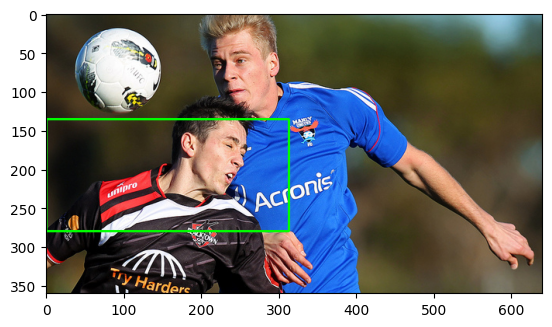

In [5]:
# it's important to make sure that ranks within the same 
# model parallel group should always receive the same input simultaneously
def replace_bounding_box_prompts(description,idx=1):
    prompts = [
        f"Identify and return the bounding box coordinates for the person described in: \"{description}\"",
        f"Generate bounding box coordinates for the person described: \"{description}\"",
        f"Output the bounding box coordinates for the individual characterized as follows: \"{description}\"",
        f"Locate and specify the bounding box coordinates for the person in this description: \"{description}\"",
        f"Calculate the bounding box coordinates for the person described here: \"{description}\"",
        f"Determine and output the bounding box coordinates for the following description of a person: \"{description}\"",
        f"Find the bounding box coordinates for the person with these details: \"{description}\"",
        f"Retrieve and display bounding box coordinates for the person whose description is: \"{description}\"",
        f"Give the bounding box coordinates for the individual described in the following: \"{description}\"",
        f"Generate the coordinates for the bounding box of the person as described here: \"{description}\""
    ]
    # randomly choose one prompt from prompts
    # gen a random index
    # idx = torch.randint(0, len(prompts), (1,)).item()

    return prompts[idx-1]

pred_bboxes=[]
start_time=time.time()
for annt in tqdm(person_annts):
    image = Image.open(os.path.join(img_folder, annt["file_name"]))
    description = annt[mode]
    qas = [[f"Provide coordinates for the bounding box around the person mentioned in: \"{description}\"", None]]
    try_idx=1
    while(try_idx<11):
        response = model.generate_response(qas, image, max_gen_len=1024, temperature=0.9, top_p=0.5, seed=0)
        try:
            pred_bbox=eval(response)
            break
        except:
            print(f"Error in response: \"{response}\" {try_idx} times")
            pred_bbox=[0,0,0,0]
            qas=[[replace_bounding_box_prompts(description,try_idx), None]]
            try_idx+=1
            print(f"Trying again with prompt: \"{qas[0][0]}\"")
            continue
    height, width = annt["height"], annt["width"]
    if(type(pred_bbox) is list):
        try:
            pred_bbox = [pred_bbox[0]*width, pred_bbox[1]*height, pred_bbox[2]*width, pred_bbox[3]*height]
        except:
            pred_bbox=[0,0,0,0]
    else:
        pred_bbox=[0,0,0,0]
    pred_bboxes.append({"pred_bbox":pred_bbox,
                        "annt_id":annt["annt_id"]})


    img=cv2.imread(os.path.join(img_folder, annt["file_name"]))
    img=cv2.rectangle(img, (int(pred_bbox[0]), int(pred_bbox[1])), (int(pred_bbox[2]), int(pred_bbox[3])), (0, 255, 0), 2)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.savefig("output.png")

    
    # print(rank,": ",response)
    # break
if(rank==0):
    print("Time taken: ", time.time()-start_time)
    #save the results
    os.makedirs(os.path.join(output_dir, mode), exist_ok=True)
    with open(os.path.join(output_dir, mode, "pred_bboxes.json"), "w") as f:
        # save with format
        json.dump(pred_bboxes, f)
        print("Results saved at: ", os.path.join(output_dir, mode, "pred_bboxes.json"))

if(use_dist):
    dist.destroy_process_group()